# Prédiction de l'age des arbres
### Projet Machine Learning - Rapport de travaux pratiques
##### Mathéo Bertin
---

## Contexte et objectif

Dans le cadre de ce projet, nous disposons d'un dataset recensant les arbres d'une ville avec différentes caractéristiques physiques (hauteur, diamètre du tronc, espèce…) ainsi qu'une estimation de leur âge (age_estim).

L'objectif est de prédire automatiquement l'age d'un arbre à partir de ses caractéristiques observables, en utilisant des algorithmes de machine learning supervisé.

Ce genre de problème est utile : un agent de terrain pourrait prendre quelques mesures et obtenir une estimation d'age sans avoir à fouiller les archives de plantation.

---

## Plan du notebook

1. Chargement des données
2. Nettoyage et sélection des variables
3. Identification des types de colonnes
4. Prétraitement
5. Séparation train/test
6. Comparaison de 4 algorithmes (baseline)
7. Optimisation par GridSearchCV
8. Graphique de comparaison avant/après optimisation
9. Visualisation des prédictions du meilleur modèle
10. Conclusion
11. Sauvegarde du meilleur modèle

---


## 1. Imports des bibliothèques

In [7]:
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

## 2. Chargement des données

In [15]:
data_path = Path("Data_Arbre_Clean.csv")
df = pd.read_csv(data_path)

print(f"Dataset: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(df.head())
print("Types de colonnes:")
print(df.dtypes)

Dataset: 11248 lignes, 37 colonnes
              X             Y  OBJECTID            created_date  \
0  1.720320e+06  8.294619e+06         1  2017/02/02 15:27:50+00   
1  1.720898e+06  8.293531e+06         2  2017/02/02 15:27:50+00   
2  1.720894e+06  8.293542e+06         3  2017/02/02 15:27:50+00   
3  1.720902e+06  8.293545e+06         4  2017/02/02 15:27:50+00   
4  1.721089e+06  8.293619e+06         5  2017/02/02 15:27:50+00   

      created_user     src_geo              clc_quartier          clc_secteur  \
0  mickael.delaere  Orthophoto  Quartier du Centre-Ville  Boulevard Richelieu   
1  mickael.delaere  Orthophoto  Quartier du Centre-Ville  Boulevard Léon Blum   
2  mickael.delaere  Orthophoto  Quartier du Centre-Ville  Boulevard Léon Blum   
3  mickael.delaere  Orthophoto  Quartier du Centre-Ville  Boulevard Léon Blum   
4  mickael.delaere  Orthophoto  Quartier du Centre-Ville  Boulevard Léon Blum   

  id_arbre  haut_tot  ...  villeca  nomfrancais nomlatin  \
0       24     

## 3. Nettoyage et sélection des variables

### Choix des features

Le dataset original contient 37 colonnes, mais beaucoup ne sont pas pertinentes pour prédire l'age (identifiants, dates de saisie, métadonnées administratives…). J'ai sélectionné 10 variables qui ont un sens pour estimer l'age d'un arbre :

| Variable | Type | Justification |
|---|---|---|
| haut_tot | Numérique | Un arbre plus agé est en général plus grand |
| haut_tronc | Numérique | La hauteur du tronc augmente avec l'age |
| tronc_diam | Numérique | Le diamètre du tronc est un indicateur classique d'age |
| clc_nbr_diag | Numérique | Nombre de diagnostics réalisés |
| fk_prec_estim | Numérique | Précision de l'estimation (info contextuelle) |
| clc_quartier | Catégorielle | Le quartier peut refléter des périodes de plantation |
| nomlatin | Catégorielle | L'espèce a une forte influence sur la croissance |
| fk_stadedev | Catégorielle | Stade de développement de l'arbre |
| fk_arb_etat | Catégorielle | État sanitaire de l'arbre |
| fk_situation | Catégorielle | Contexte de plantation (rue, parc…) |

### Gestion des valeurs manquantes

On supprime uniquement les lignes où age_estim est manquante. Pour les features, les valeurs manquantes seront gérées plus tard dans le pipeline de prétraitement via des SimpleImputer.

> **Problème rencontré** : Dans une version antérieure du code, age_estim était incluse par erreur dans num_columns (les colonnes numériques passées au préprocesseur). Cela causait un KeyError au moment du .fit(), car X_train ne contient pas la cible. Ce bug a été corrigé en construisant X avant de détecter les types de colonnes.


In [16]:
target = "age_estim"

colonnes_selectionnees = [
    "haut_tronc",
    "tronc_diam",
    "clc_quartier",
    "nomlatin",
    "haut_tot",
    "fk_stadedev",
    "fk_arb_etat",
    "fk_situation",
    "clc_nbr_diag",
    "fk_prec_estim",
]

df = df[colonnes_selectionnees + [target]].copy()
df = df.dropna(subset=[target])
print(f"Dataset après nettoyage : {df.shape}")

X = df[colonnes_selectionnees]
y = df[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Dataset après nettoyage : (10415, 11)
X shape: (10415, 10)
y shape: (10415,)


## 4. Identification des types de colonnes

Les algorithmes de machine learning travaillent uniquement avec des nombres. Les colonnes textuelles (object) doivent être encodées, et les colonnes numériques doivent être normalisées. On ne peut donc pas appliquer le même traitement aux deux types : il faut les traiter séparément.

select_dtypes permet de récupérer automatiquement les colonnes selon leur type, ce qui est plus robuste que de les lister manuellement (si le dataset change, le code s'adapte tout seul).

> **Problème rencontré et correction** : La première version du code appliquait select_dtypes sur df (qui contenait encore age_estim). Résultat : age_estim se retrouvait dans num_columns et le ColumnTransformer cherchait cette colonne dans X_train où elle n'existait plus. La correction a été de faire la détection sur X uniquement, après avoir séparé features et target.


In [17]:
# On détecte les types de colonnes depuis X (sans age_estim)
cat_columns = X.select_dtypes(include=["object", "str"]).columns.tolist()
num_columns = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Colonnes catégorielles ({len(cat_columns)}): {cat_columns}")
print(f"Colonnes numériques ({len(num_columns)}): {num_columns}")

Colonnes catégorielles (5): ['clc_quartier', 'nomlatin', 'fk_stadedev', 'fk_arb_etat', 'fk_situation']
Colonnes numériques (5): ['haut_tronc', 'tronc_diam', 'haut_tot', 'clc_nbr_diag', 'fk_prec_estim']


## 5. Prétraitement

#### Pour les colonnes catégorielles :
1. **SimpleImputer(strategy="most_frequent")** : remplace les valeurs manquantes par la valeur la plus fréquente de la colonne.
2. **OneHotEncoder** : transforme chaque texte en une colonne binaire (0/1). handle_unknown="ignore" évite les erreurs si le jeu de test contient des modalités inconnues. sparse_output=False retourne un tableau plus facile à manipuler.

#### Pour les colonnes numériques :
1. **SimpleImputer(strategy="median")** : remplace les manquants par la médiane. J'ai choisi la médiane plutôt que la moyenne car elle est plus robuste aux valeurs aberrantes.
2. **StandardScaler** : centre et réduit les données (moyenne = 0, écart-type = 1). Indispensable pour SVR et LinearRegression qui sont sensibles aux échelles différentes entre variables.


In [18]:
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # valeur la plus fréquente pour les catégories
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # encodage one-hot
])

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # médiane pour les valeurs manquantes
    ("scaler", StandardScaler())  # normalisation
])

# ColumnTransformer applique cat_transformer sur les colonnes texte
# et num_transformer sur les colonnes numériques
preprocessor = ColumnTransformer([
    ("cat", cat_transformer, cat_columns),
    ("num", num_transformer, num_columns)
])

## 6. Séparation train / test

Le split 80% entraînement / 20% test est un standard en ML pour des datasets de taille moyenne (~10 000 lignes). Il laisse suffisamment de données pour entraîner les modèles tout en gardant un échantillon de test représentatif.

Le random_state=42 est fixé pour garantir la reproductibilité : si quelqu'un re-exécute le notebook, il obtiendra exactement les mêmes ensembles train/test que nous.

In [19]:
RANDOM_STATE = 42  # fixé pour la reproductibilité des résultats

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train set: {X_train.shape[0]} lignes")
print(f"Test set:  {X_test.shape[0]} lignes")
print(f"Stats target train : mean={y_train.mean():.2f}, std={y_train.std():.2f}, min={y_train.min():.2f}, max={y_train.max():.2f}")
print(f"Stats target test  : mean={y_test.mean():.2f}, std={y_test.std():.2f}, min={y_test.min():.2f}, max={y_test.max():.2f}")

Train set: 8332 lignes
Test set:  2083 lignes
Stats target train : mean=31.28, std=20.36, min=0.00, max=200.00
Stats target test  : mean=31.76, std=20.34, min=0.00, max=200.00


## 7. Comparaison des 4 algorithmes (baseline)

### Pourquoi ces 4 algorithmes ?

L'idée est de tester différentes approches, du plus simple au plus complexe, pour voir lequel convient le mieux à ce problème :

| Modèle | Type | Avantages | Inconvénients |
|---|---|---|---|
| LinearRegression | Linéaire | Rapide, interprétable | Limité si relations non-linéaires |
| SVR | Noyau | Robuste, flexible avec le bon kernel | Lent sur gros datasets, sensible aux paramètres |
| RandomForest | Ensemble (bagging) | Robuste aux outliers, peu de réglage | Moins performant que le boosting sur certains problèmes |
| GradientBoosting | Ensemble (boosting) | Souvent très performant | Plus lent à entraîner, plus de paramètres |

### Métriques choisies

- **R²** : proportion de variance expliquée. Un R² de 1.0 = prédiction parfaite, 0 = modèle nul. C'est la métrique principale pour comparer les modèles.
- **MAE** (Mean Absolute Error) : erreur moyenne en années. Facile à interpréter : "en moyenne, le modèle se trompe de X ans".
- **RMSE** (Root Mean Squared Error) : pénalise davantage les grandes erreurs que le MAE. Utile pour détecter si le modèle fait quelques erreurs très importantes.

On calcule les métriques à la fois sur train et test pour détecter un éventuel sur-apprentissage (overfitting) : si le R² train est très élevé mais le R² test est faible, le modèle a mémorisé les données au lieu d'apprendre.

### Structure Pipeline

Chaque modèle est encapsulé dans un Pipeline scikit-learn qui chaîne le préprocesseur et le modèle. Cela garantit que le preprocessing est appliqué de manière cohérente à chaque appel de .fit() et .predict().


In [20]:
# Fonction pour calculer les 3 métriques d'un coup
def calculer_metriques(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)   # erreur absolue moyenne
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # racine de l'erreur quadratique
    r2   = r2_score(y_true, y_pred)  # coefficient de détermination
    return mae, rmse, r2

# Chaque modèle est un Pipeline : preprocessing + algorithme
modeles_baseline = {
    # Le modèle essaie de trouver une fonction qui reste dans une “zone de tolérance” autour des données, tout en étant la plus simple possible.
    "RandomForest": Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
        # n_estimators=200 : 200 arbres
        # n_jobs=-1 : utilise tous les coeurs CPU disponibles
    ]),
    # Un modèle d’ensemble plus “intelligent” que RandomForest.
    "GradientBoosting": Pipeline([
        ("preprocessing", preprocessor),
        ("model", GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE))
    ]),
    # Le modèle essaie de trouver une fonction qui reste dans une “zone de tolérance” autour des données, tout en étant la plus simple possible.
    "SVR": Pipeline([
        ("preprocessing", preprocessor),
        ("model", SVR())
    ]),
    # il cherche une relation linéaire entre les variables d’entrée (features) et la sortie (target)
    "LinearRegression": Pipeline([
        ("preprocessing", preprocessor),
        ("model", LinearRegression())
    ]),
}

resultats_baseline = {}  # dictionnaire pour stocker les résultats de chaque modèle

for nom, modele in modeles_baseline.items():
    print(f"Entraînement : {nom}...")
    modele.fit(X_train, y_train)  # entraînement

    pred_train = modele.predict(X_train)  # prédictions sur train (pour détecter l'overfitting)
    pred_test  = modele.predict(X_test)   # prédictions sur test (performance réelle)

    train_mae, train_rmse, train_r2 = calculer_metriques(y_train, pred_train)
    test_mae,  test_rmse,  test_r2  = calculer_metriques(y_test,  pred_test)

    # Stockage des résultats pour comparaison ultérieure
    resultats_baseline[nom] = {
        "modele": modele,
        "r2": test_r2, "mae": test_mae, "rmse": test_rmse,
        "train_r2": train_r2, "train_mae": train_mae, "train_rmse": train_rmse,
    }
    print(f"  Train R²={train_r2:.4f} | Test R²={test_r2:.4f} | MAE={test_mae:.2f} | RMSE={test_rmse:.2f}")

# Sélection du meilleur modèle baseline selon le R² test
meilleur_baseline = max(resultats_baseline, key=lambda x: resultats_baseline[x]["r2"])
print(f"Meilleur modèle baseline : {meilleur_baseline} (R²={resultats_baseline[meilleur_baseline]['r2']:.4f})")

Entraînement : RandomForest...
  Train R²=0.9932 | Test R²=0.9505 | MAE=1.99 | RMSE=4.53
Entraînement : GradientBoosting...
  Train R²=0.9236 | Test R²=0.9110 | MAE=4.20 | RMSE=6.07
Entraînement : SVR...
  Train R²=0.8174 | Test R²=0.8259 | MAE=4.37 | RMSE=8.48
Entraînement : LinearRegression...
  Train R²=0.8571 | Test R²=0.8477 | MAE=5.58 | RMSE=7.93
Meilleur modèle baseline : RandomForest (R²=0.9505)


## 8. Optimisation GridSearchCV pour chaque modèle

Les modèles de machine learning ont des hyperparamètres : des réglages qui ne sont pas appris pendant l'entraînement mais fixés à l'avance. Par exemple, combien d'arbres dans une forêt aléatoire ? Quelle profondeur maximale ?

GridSearchCV teste toutes les combinaisons possibles d'hyperparamètres sur une grille définie, en utilisant la validation croisée (ici cv=5 : le dataset train est découpé en 5 parties, le modèle est entraîné 5 fois en utilisant à tour de rôle chaque partie comme validation). On garde ensuite la combinaison qui donne le meilleur score moyen.


### Grilles de paramètres choisies

- **RandomForest** : on fait varier le nombre d'arbres (n_estimators), la profondeur maximale (max_depth) et le nombre minimum d'échantillons pour splitter un nœud (min_samples_split).
- **GradientBoosting** : on ajoute le learning_rate (taux d'apprentissage). Un learning rate faible avec beaucoup d'estimateurs donne souvent de meilleurs résultats mais est plus lent.
- **SVR** : on teste différentes valeurs de C (régularisation), epsilon (marge de tolérance) et kernel (fonction de noyau).
- **LinearRegression** : pas d'hyperparamètres à optimiser. On réutilise directement le modèle baseline.

### Scoring r2

On utilise le R² comme critère de sélection car c'est la métrique la plus interprétable pour une régression.


In [21]:
# Grilles d'hyperparamètres à tester pour chaque modèle
grilles_parametres = {
    "RandomForest": {
        "model__n_estimators": [100, 200, 300], # nombre d'arbres dans la forêt
        "model__max_depth": [10, 20, None], # None = pas de limite de profondeur
        "model__min_samples_split": [2, 5], # min d'échantillons pour diviser un nœud
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200], # nombre d'étapes de boosting
        "model__max_depth": [3, 5, 7], # profondeur de chaque arbre individuel
        "model__learning_rate": [0.05, 0.1, 0.2], # taux d'apprentissage
    },
    "SVR": {
        "model__C": [0.1, 1, 10], # force de régularisation (tolérence au erreur)
        "model__epsilon": [0.1, 0.5, 1.0], # largeur du tube sans pénalité, Grand epsilon = moins sensible aux petites erreurs
        "model__kernel": ["rbf", "linear"], # fonction noyau (linéraire ou non linéaire)
    },
    "LinearRegression": {},  # pas d'hyperparamètres (on garde le modèle baseline tel quel)
}

# Nouveaux pipelines vierges pour le GridSearch (on repart de zéro, sans les poids du baseline)
pipelines_base = {
    "RandomForest": Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "GradientBoosting": Pipeline([
        ("preprocessing", preprocessor),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
    ]),
    "SVR": Pipeline([
        ("preprocessing", preprocessor),
        ("model", SVR())
    ]),
    "LinearRegression": Pipeline([
        ("preprocessing", preprocessor),
        ("model", LinearRegression())
    ]),
}

resultats_optimises = {}  # stockage des résultats après optimisation

for nom, grille in grilles_parametres.items():
    print(f"GridSearch : {nom}...")

    if grille:
        # GridSearchCV : teste toutes les combinaisons par validation croisée
        gs = GridSearchCV(
            pipelines_base[nom], grille,
            cv=5,
            scoring="r2",
            n_jobs=-1,
            verbose=0
        )
        gs.fit(X_train, y_train)
        meilleur_pipeline = gs.best_estimator_  # pipeline avec les meilleurs paramètres trouvés
        best_params = gs.best_params_
        print(f"Meilleurs paramètres : {best_params}")
        print(f"Meilleur score CV : {gs.best_score_:.4f}")
    else:
        # LinearRegression : pas de GridSearch possible, on récupère le modèle baseline
        meilleur_pipeline = resultats_baseline[nom]["modele"]
        best_params = {}

    # Évaluation du modèle optimisé sur train et test
    pred_train = meilleur_pipeline.predict(X_train)
    pred_test  = meilleur_pipeline.predict(X_test)

    train_mae, train_rmse, train_r2 = calculer_metriques(y_train, pred_train)
    test_mae,  test_rmse,  test_r2  = calculer_metriques(y_test,  pred_test)

    resultats_optimises[nom] = {
        "modele": meilleur_pipeline,
        "best_params": best_params,
        "r2": test_r2, "mae": test_mae, "rmse": test_rmse,
        "train_r2": train_r2, "train_mae": train_mae, "train_rmse": train_rmse,
    }
    print(f"Test R²={test_r2:.4f} | MAE={test_mae:.2f} | RMSE={test_rmse:.2f}")

# Sélection finale : le modèle avec le meilleur R² test après optimisation
meilleur_modele = max(resultats_optimises, key=lambda x: resultats_optimises[x]["r2"])
meilleur_pipeline_final = resultats_optimises[meilleur_modele]["modele"]
print(f"Meilleur modèle optimisé : {meilleur_modele} (R²={resultats_optimises[meilleur_modele]['r2']:.4f})")

GridSearch : RandomForest...
Meilleurs paramètres : {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Meilleur score CV : 0.9486
Test R²=0.9506 | MAE=1.99 | RMSE=4.52
GridSearch : GradientBoosting...
Meilleurs paramètres : {'model__learning_rate': 0.2, 'model__max_depth': 7, 'model__n_estimators': 200}
Meilleur score CV : 0.9445
Test R²=0.9434 | MAE=2.49 | RMSE=4.84
GridSearch : SVR...
Meilleurs paramètres : {'model__C': 10, 'model__epsilon': 1.0, 'model__kernel': 'rbf'}
Meilleur score CV : 0.8870
Test R²=0.9061 | MAE=3.05 | RMSE=6.23
GridSearch : LinearRegression...
Test R²=0.8477 | MAE=5.58 | RMSE=7.93
Meilleur modèle optimisé : RandomForest (R²=0.9506)


## 9. Graphique de comparaison avant/après GridSearch

On affiche 3 graphiques en barres groupées (Baseline vs GridSearch) pour les 3 métriques principales : R², MAE et RMSE. Les barres plus claires représentent le baseline, les plus foncées l'après-optimisation.


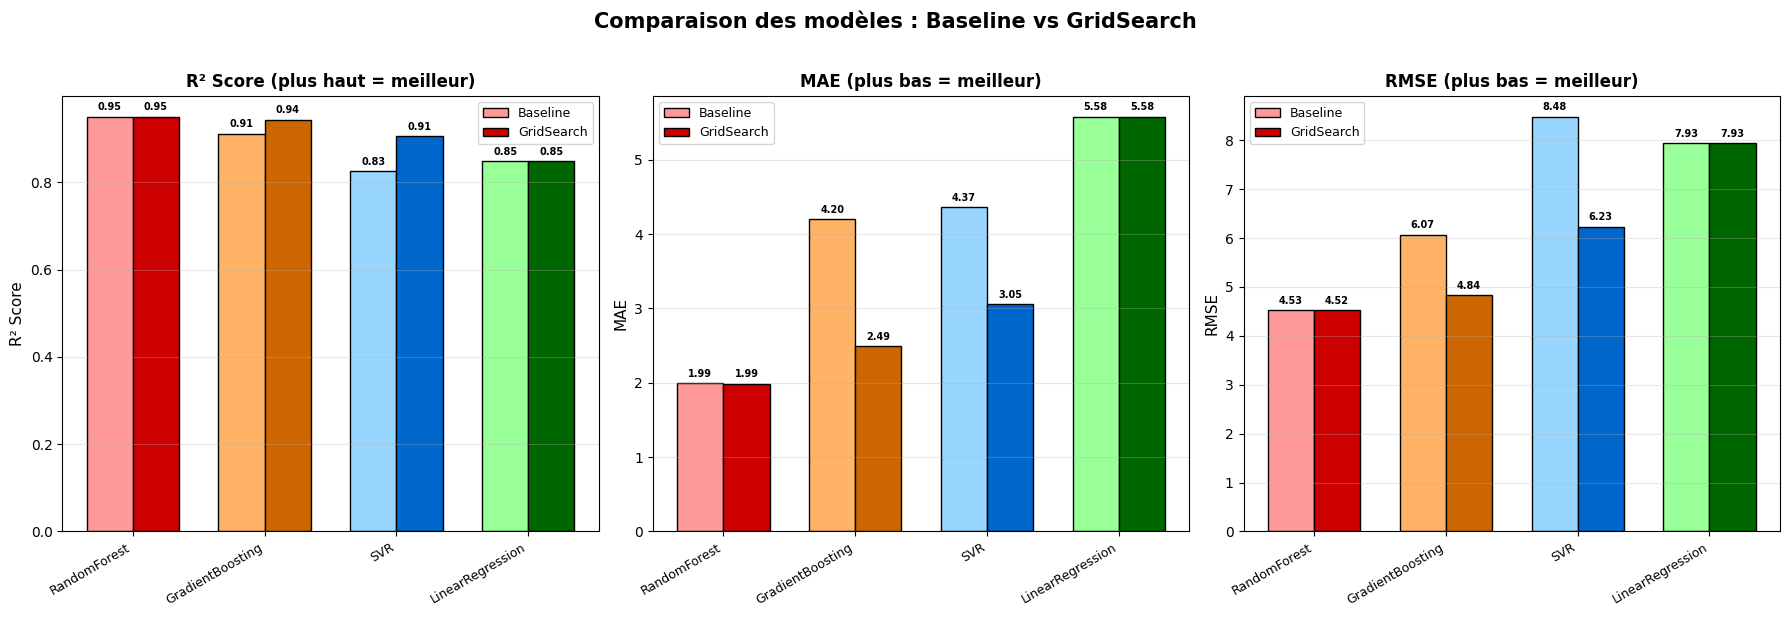

Graphique sauvegardé : comparaison_modeles.png


In [22]:
noms = list(resultats_baseline.keys())
x = np.arange(len(noms))
width = 0.35

# Couleurs claires = baseline, couleurs foncées = après GridSearch
couleurs_avant = ["#FF9999", "#FFB366", "#99D6FF", "#99FF99"]
couleurs_apres = ["#CC0000", "#CC6600", "#0066CC", "#006600"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Comparaison des modèles : Baseline vs GridSearch", fontsize=15, fontweight="bold", y=1.02)

# On boucle sur les 3 métriques pour générer les 3 sous-graphiques
metriques = [
    ("r2", "R² Score", "R² Score (plus haut = meilleur)"),
    ("mae", "MAE", "MAE (plus bas = meilleur)"),
    ("rmse", "RMSE", "RMSE (plus bas = meilleur)"),
]

for ax, (cle, label, titre) in zip(axes, metriques):
    vals_avant = [resultats_baseline[n][cle]  for n in noms]  # valeurs baseline
    vals_apres = [resultats_optimises[n][cle] for n in noms]  # valeurs après GridSearch

    bars1 = ax.bar(x - width/2, vals_avant, width, label="Baseline",  color=couleurs_avant, edgecolor="black", linewidth=1)
    bars2 = ax.bar(x + width/2, vals_apres, width, label="GridSearch", color=couleurs_apres, edgecolor="black", linewidth=1)

    ax.set_title(titre, fontsize=12, fontweight="bold")
    ax.set_ylabel(label, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(noms, rotation=30, ha="right", fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

    # Affichage des valeurs au-dessus de chaque barre pour faciliter la lecture
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ax.get_ylim()[1]*0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7, fontweight="bold")
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ax.get_ylim()[1]*0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.savefig("comparaison_modeles.png", dpi=150, bbox_inches="tight")  # sauvegarde du graphique
plt.show()
print("Graphique sauvegardé : comparaison_modeles.png")

## 10. Prédictions vs Réalité - meilleur modèle

La droite en pointillés rouges représente la prédiction parfaite (y_pred = y_true). Plus les points s'en rapprochent, meilleur est le modèle.

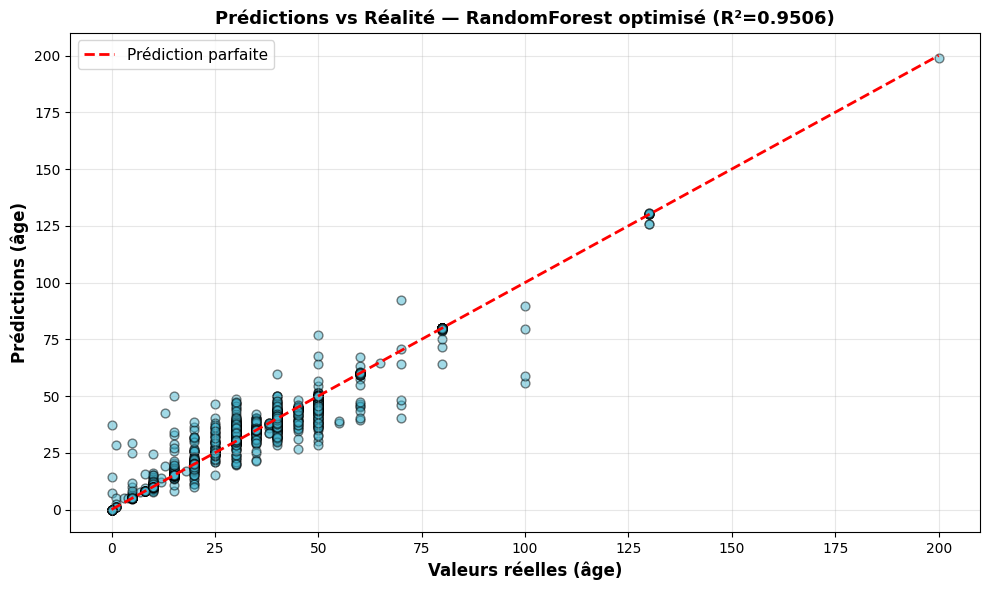

In [23]:
# Récupération des métriques du meilleur modèle pour l'affichage
r2_test  = resultats_optimises[meilleur_modele]["r2"]
mae_test = resultats_optimises[meilleur_modele]["mae"]
rmse_test = resultats_optimises[meilleur_modele]["rmse"]
r2_train  = resultats_optimises[meilleur_modele]["train_r2"]
mae_train = resultats_optimises[meilleur_modele]["train_mae"]
rmse_train = resultats_optimises[meilleur_modele]["train_rmse"]

# Prédictions du meilleur pipeline sur le jeu de test
predictions_test = meilleur_pipeline_final.predict(X_test)

plt.figure(figsize=(10, 6))
# Chaque point = un arbre du jeu de test (x=age réel, y=age prédit)
plt.scatter(y_test, predictions_test, alpha=0.5, edgecolors="black", s=40, color="#45B7D1")

# Droite de prédiction parfaite (y = x)
min_val = min(y_test.min(), predictions_test.min())
max_val = max(y_test.max(), predictions_test.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Prédiction parfaite")

plt.xlabel("Valeurs réelles (âge)", fontsize=12, fontweight="bold")
plt.ylabel("Prédictions (âge)", fontsize=12, fontweight="bold")
plt.title(f"Prédictions vs Réalité — {meilleur_modele} optimisé (R²={r2_test:.4f})", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Conclusion

### Bilan de l'expérience

Ce bloc affiche un récapitulatif complet des résultats pour tous les modèles, avant et après optimisation, avec le delta de R² pour mesurer l'apport du GridSearchCV.

On analyse aussi l'écart de généralisation (R² train - R² test) : un écart important signale de l'overfitting. Idéalement, on cherche un modèle avec un bon R² test et un faible écart train/test.

In [24]:
print("Conclusion")

# Tableau comparatif baseline
print("Résultats baseline (sans optimisation) :")
for nom in noms:
    r = resultats_baseline[nom]
    print(f"{nom:<20}, R²={r['r2']:.4f}, MAE={r['mae']:.2f}, RMSE={r['rmse']:.2f}")

# Tableau comparatif après GridSearch avec delta de R²
print("Résultats après GridSearchCV :")
for nom in noms:
    r = resultats_optimises[nom]
    delta = r["r2"] - resultats_baseline[nom]["r2"]
    signe = "+" if delta >= 0 else ""
    print(f"{nom:<20}, R²={r['r2']:.4f}, MAE={r['mae']:.2f}, RMSE={r['rmse']:.2f}  (ΔR²={signe}{delta:.4f})")

print(f"Meilleur modèle sélectionné : {meilleur_modele}")
print(f"R² Train : {r2_train:.4f}")
print(f"R² Test  : {r2_test:.4f}")
print(f"MAE Test : {mae_test:.2f} ans") # erreur moyenne en années
print(f"RMSE Test: {rmse_test:.2f} ans")
print(f"Écart généralisation (train-test) : {r2_train - r2_test:.4f}")

Conclusion
Résultats baseline (sans optimisation) :
RandomForest        , R²=0.9505, MAE=1.99, RMSE=4.53
GradientBoosting    , R²=0.9110, MAE=4.20, RMSE=6.07
SVR                 , R²=0.8259, MAE=4.37, RMSE=8.48
LinearRegression    , R²=0.8477, MAE=5.58, RMSE=7.93
Résultats après GridSearchCV :
RandomForest        , R²=0.9506, MAE=1.99, RMSE=4.52  (ΔR²=+0.0002)
GradientBoosting    , R²=0.9434, MAE=2.49, RMSE=4.84  (ΔR²=+0.0324)
SVR                 , R²=0.9061, MAE=3.05, RMSE=6.23  (ΔR²=+0.0802)
LinearRegression    , R²=0.8477, MAE=5.58, RMSE=7.93  (ΔR²=+0.0000)
Meilleur modèle sélectionné : RandomForest
R² Train : 0.9932
R² Test  : 0.9506
MAE Test : 1.99 ans
RMSE Test: 4.52 ans
Écart généralisation (train-test) : 0.0426


## 12. Sauvegarde du meilleur modèle

In [25]:
modele_path = "modele_arbre.pkl"
joblib.dump(meilleur_pipeline_final, modele_path)
print(f"Modèle sauvegardé : {modele_path}")

Modèle sauvegardé : modele_arbre.pkl
